In [13]:
import numpy as np
import orbitengine.engine as oe
import astropy.units as u
from poliastro.bodies import Earth
from scipy.optimize import minimize
from orbitengine.body import Body
import orbitengine.transfer
from orbitengine.transfer import TransferSolver, ThrustManeuver
import time
from scipy.spatial.transform import Rotation as R
import matplotlib.pyplot as plt
from poliastro import iod
import pickle
import math
import os
from pprint import pprint
import importlib

np.set_printoptions(precision=2)

engine.py:106  Loaded from cache\TransferSolver_460a4487872b7a26e6352e48cb19b814.pkl


C:\Users\jcl5m\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\integrate\_ode.py:1179: UserWarning: dopri5: step size becomes too small
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


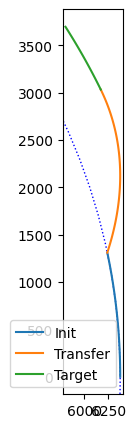

3715747827.py:25  (<Quantity 2848.4 s>, <Quantity 402.85 s>, <orbitengine.body.Body.State object at 0x000002063168D450>)


In [20]:

# rocket on ground
r0 = np.array([oe.EARTH_RADIUS_KM.value, 0, 0])*u.km
ground_velocity = oe.EARTH_RADIUS_KM*2*np.pi/(24*3600*u.s)
v0 = np.array([0, ground_velocity.value, 0])*u.km/u.s
m0 = 100000*u.kg # rocket + fuel
#m0 = 10000*u.kg # rocket + fuel
dry_mass =  500*u.kg #rocket only
T0 = oe.TEMP_EARTH
isp = oe.SPECIFIC_IMPULSE_TYPE.Liquid
state_launch = Body.State( r0, v0, m0, T0, parent_axis_angle=oe.EARTH_AXIS_ANGLE)
cache = True
# compute a target in circular orbit
state_leo = Body.State(np.array([-oe.ALTITUDE_LEO.value, 0, 0])*u.km,
                       np.array([0, -5, 0])*u.km/u.s,   # guess
                        m0,
                        T0).circularized(oe.EARTH_K)
state_geo = Body.State(np.array([-oe.ALTITUDE_GEO.value, 0, 0])*u.km,
                       np.array([0, -5, 0])*u.km/u.s,   # guess
                        m0,
                        T0).circularized(oe.EARTH_K)

#solver = TransferSolver(state_launch, state_geo, oe.EARTH_K, time_weight=0.0001)
solver = TransferSolver(state_launch, state_leo, oe.EARTH_K, time_weight=0.0001)
#solver = TransferSolver(state_leo, state_geo, oe.EARTH_K, time_weight=0.0001)
oe.print(solver.lambert_search(resolution=10, plot=True, cache=cache))


engine.py:106  Loaded from cache\ThrustManeuver_505e990a68e49c92f56d28dc369d1c06.pkl
engine.py:106  Loaded from cache\ThrustManeuver_58970c2afbfe16a09ef578a1149a1936.pkl
Post M1 mass: 33958.42 kg
Post M2 mass: 15169.49 kg
m1_dV:4.66 m2_dV:3.56  total_dV: 8.21
Initial Mass: 100000.00 kg Final Mass: 15169.49 kg
Reaction Mass Remaining: 14669.488338418365 kg
Delay, Flight: 2848.40 s, 402.85 s
m1_init_burn: 19.65 s, m1_correction_burn: 13.37 s, alignment_err: 3.971822722450305e-10
m2_init_burn: 5.32 s, m2_correction_burn: 4.07 s, alignment_err: 6.589968191096884e-09


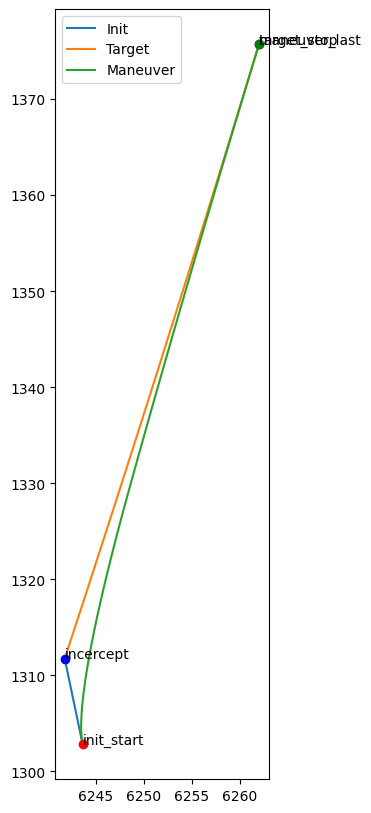

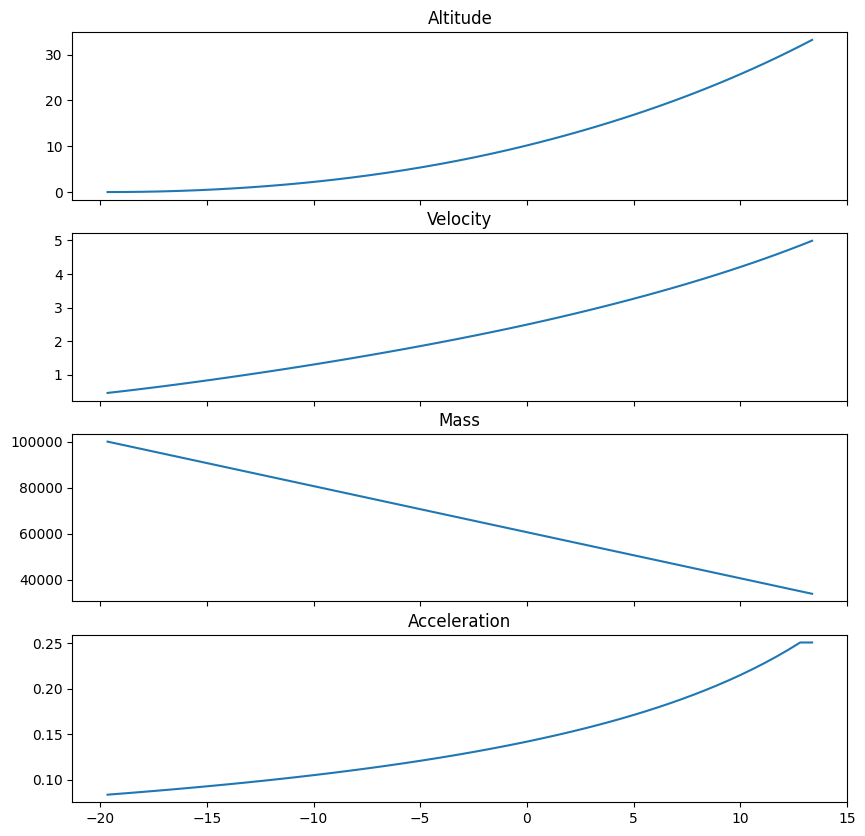

Post Maneuver Mass: 33958.41987541521 kg


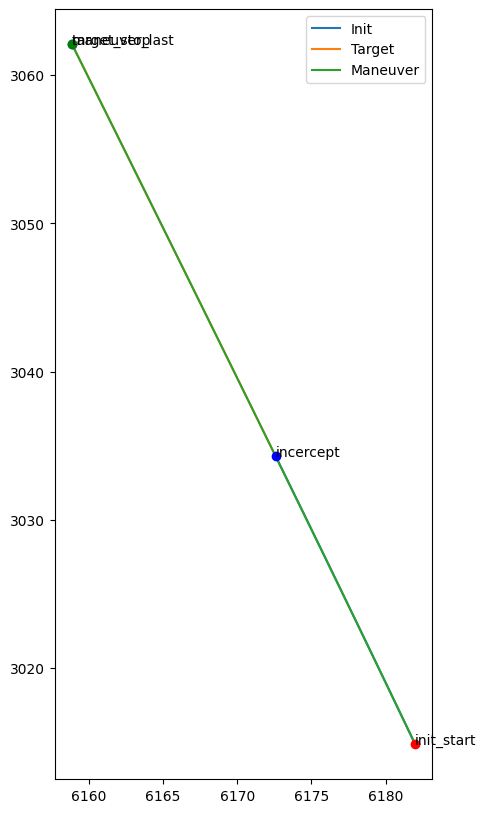

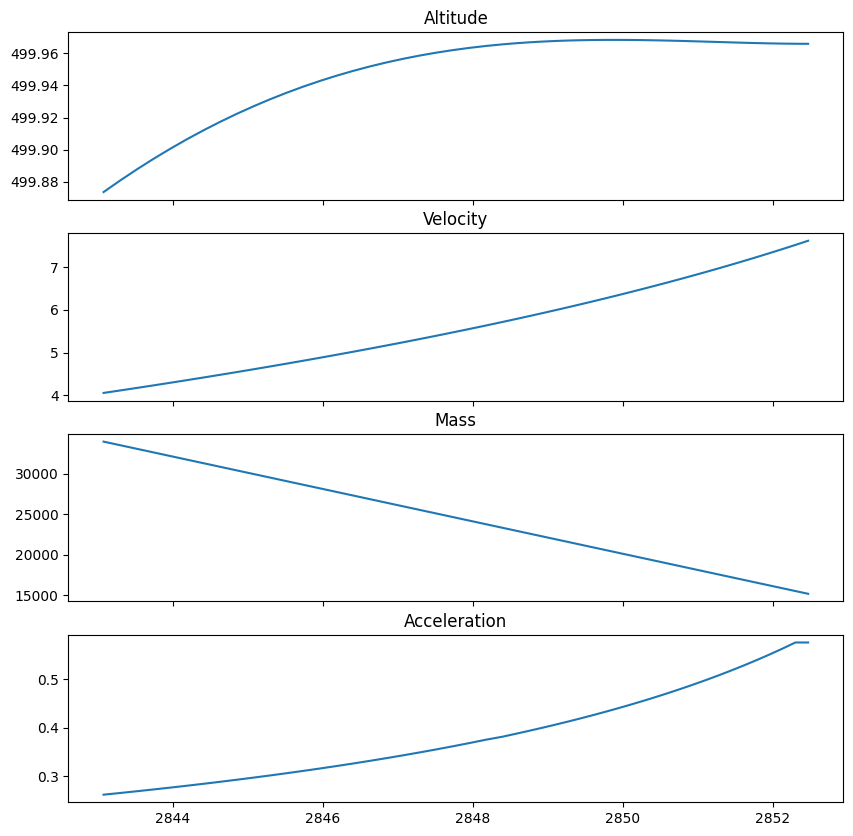

Post Maneuver Mass: 15169.488338418365 kg


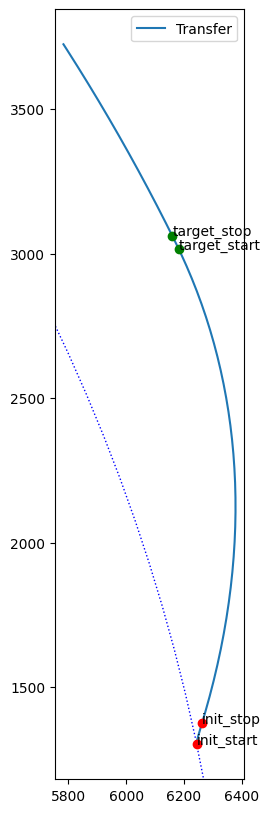

In [21]:
# compute thrust limited maneuvers
flow_rate = 1.0*oe.FALCON9_REACTION_MASS_FLOW_RATE

res = solver.compute_thrust_maneuvers(flow_rate, isp, dry_mass, verbose=False, cache=cache)

if res is not None:
    state, err = res
#    print(state)
    print(f"Post M1 mass: {solver.maneuver1.state_post_maneuver.mass:.02f}")
    print(f"Post M2 mass: {solver.maneuver2.state_post_maneuver.mass:.02f}")
    print(f"m1_dV:{solver.dv1:.02f} m2_dV:{solver.dv2:.02f}  total_dV: {solver.dv1+solver.dv2:.02f}")
    print(f"Initial Mass: {m0:.02f} Final Mass: {state.mass:.02f}")
    print(f"Reaction Mass Remaining: {state.mass - dry_mass}")
    print(f"Delay, Flight: {solver.t_delay:.02f}, {solver.t_flight:.02f}")
    print(f"m1_init_burn: {solver.maneuver1.t_init_burn:.02f}, m1_correction_burn: {solver.maneuver1.t_correction_burn:.02f}, alignment_err: {solver.maneuver1.alignment_err}")
    print(f"m2_init_burn: {solver.maneuver2.t_init_burn:.02f}, m2_correction_burn: {solver.maneuver2.t_correction_burn:.02f}, alignment_err: {solver.maneuver2.alignment_err}")
    solver.plot_thrust_transfer_trajectory(show_maneuvers=True, t_postfix=100*u.s)


In [4]:
import cProfile

def profile():
    flow_rate = 0.01*oe.FALCON9_REACTION_MASS_FLOW_RATE
    res = solver.compute_thrust_maneuvers(flow_rate, isp, dry_mass, verbose=False)
    state, err = res
    print(state, err)
#cProfile.run('profile()', sort='cumtime')
